# Glass Type Identification

## **problem definition**

I'm predicting the type of glass. This is a classification problem where the target variable is the type of glass. Success is defined by achieving a high f1 score, which balances both precision and recall. The features available for prediction include the physical property of the glass (Refractive index) and its chemical composition (Sodium, Magnesium, Aluminum, Silicon, Potassium, Calcium, Barium, Iron).

**Data Source:** https://www.kaggle.com/datasets/uciml/glass/data

## **Data Understanding**

In [52]:
# Used Libraries and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.visualization import plot_feature_distribution
from utils.eda import suspicious_values, get_most_suspicious_values

In [53]:
# loading the data
df = pd.read_csv("../data/glass.csv")

# removing exact duplicates
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [54]:
df.shape

(214, 10)

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [56]:
# fixing data types
df['Type'] = df['Type'].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   RI      214 non-null    float64 
 1   Na      214 non-null    float64 
 2   Mg      214 non-null    float64 
 3   Al      214 non-null    float64 
 4   Si      214 non-null    float64 
 5   K       214 non-null    float64 
 6   Ca      214 non-null    float64 
 7   Ba      214 non-null    float64 
 8   Fe      214 non-null    float64 
 9   Type    214 non-null    category
dtypes: category(1), float64(9)
memory usage: 15.4 KB


In [57]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000


In [58]:
df.isnull().sum().sum() # total number of null values

np.int64(0)

Dataset is clean and there is no missing data.

In [59]:
df[df.duplicated(keep=False)]

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
38,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1
39,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1


Samples 38 and 39 are exact duplicates of each other so I decided to remove the sample 38.

In [60]:
# removing exact duplicates
df = df.drop_duplicates(keep="first").reset_index(drop=True)
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
208,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
209,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
210,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
211,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


**Feature Meanings:**

1. **RI:** Refractive index of the glass.
2. **Na:** Sodium concentration in the glass.
3. **Mg:** Magnesium concentration in the glass.
4. **Al:** Aluminum concentration in the glass.
5. **Si:** Silicon concentration in the glass.
6. **K:** Potassium concentration in the glass.
7. **Ca:** Calcium concentration in the glass.
8. **Ba:** Barium concentration in the glass.
9. **Fe:** Iron concentration in the glass.
10. **Type:** Glass type.

**Unit Measurements:**

Weight percent in corresponding oxide, except for the Refractive Index.

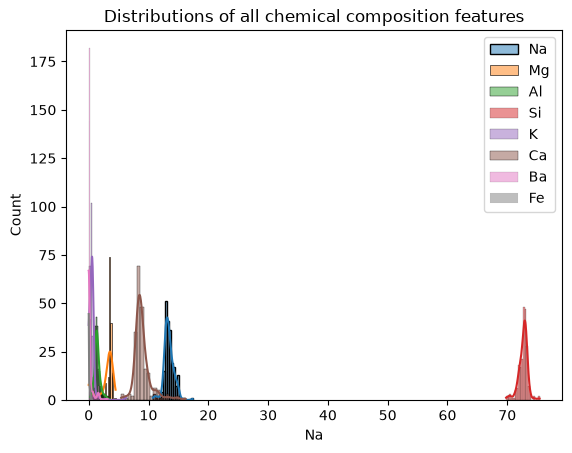

In [61]:
for feature in df.columns[1:-1]:
    sns.histplot(
		data=df,
		x=feature,
        label=f"{feature}",
		bins=20,
		kde=True,
	)
plt.title("Distributions of all chemical composition features")
plt.legend(loc="upper right")
plt.show()

There is a pattern that we can see at first it't obvious that the range of Si is much bigger than the range of other chemical compositions and it's because of the fact that Si is the most abundant element in the glasses.

> **Note:** Another insight is we should normalize the data before we start to train the models like Logistic Regression, SVM, KNN, etc.

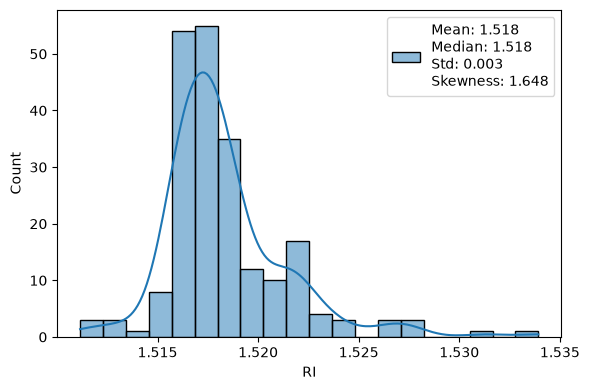

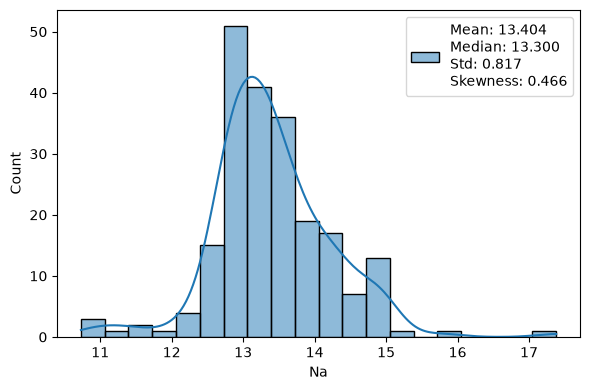

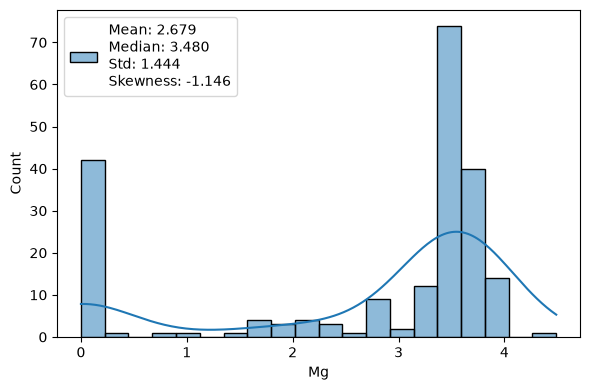

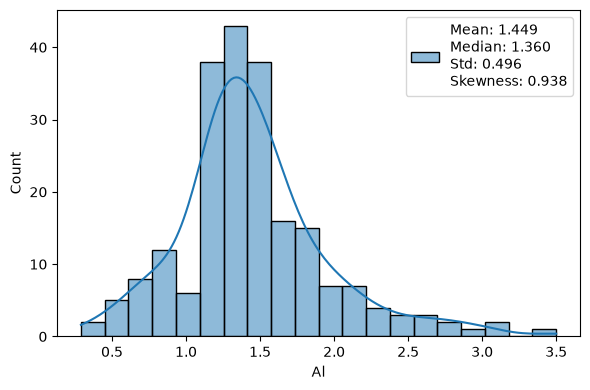

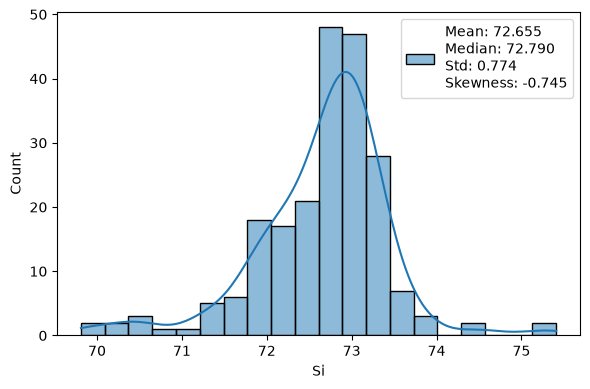

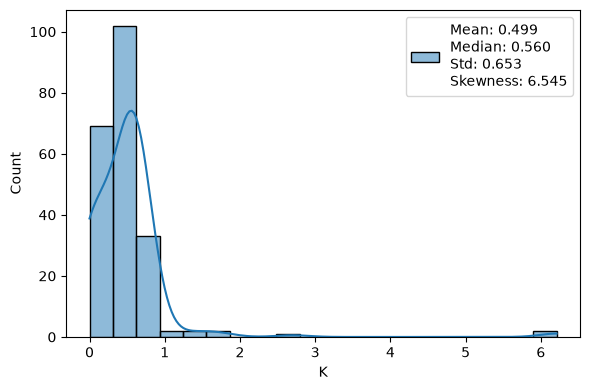

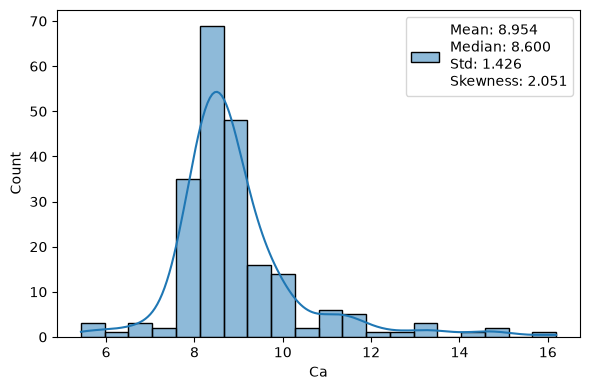

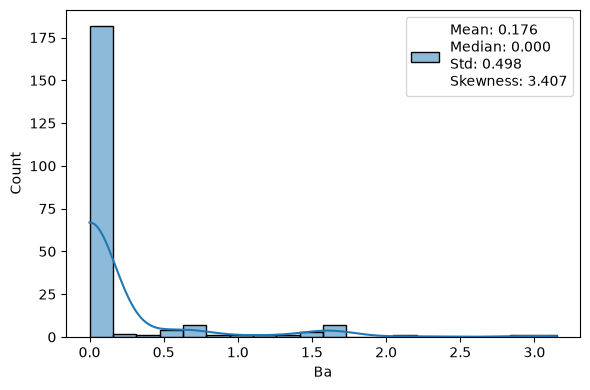

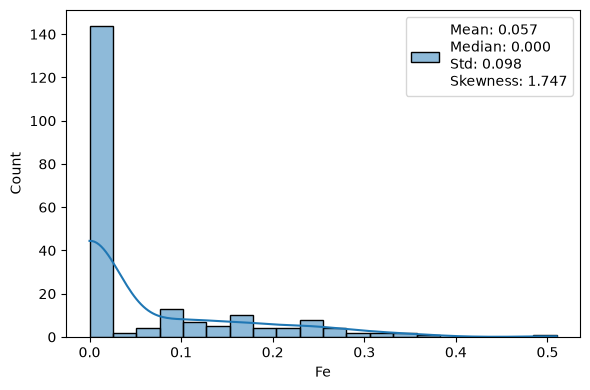

In [62]:
plot_feature_distribution(df)

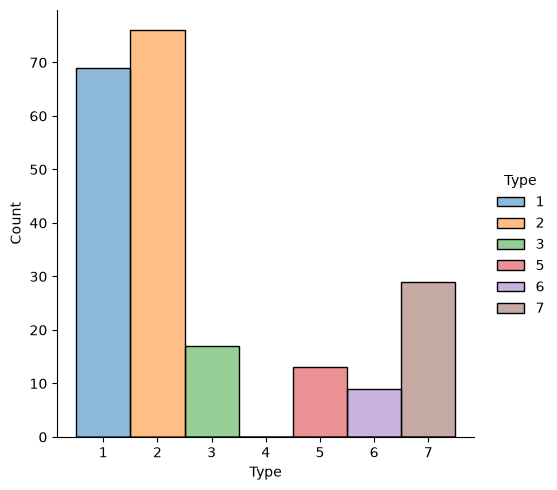

In [63]:
sns.displot(
	data=df,
    x="Type",
    hue="Type",
)

We are dealing with a high imbalance dataset.

Another thing is that we can't classify the glass type 4 (vehicle_windows_non_float_processed) cause there is no data for it.

In [64]:
for feature in df.columns[:-1]:
	print(f"{feature}: suspicious values: {suspicious_values(df[feature])}")

get_most_suspicious_values(df, threshold=2)

RI: suspicious values: [105, 106, 111]
Na: suspicious values: [105, 183]
Mg: suspicious values: []
Al: suspicious values: [162, 170, 171]
Si: suspicious values: [105, 106, 162, 183, 187, 200]
K: suspicious values: [170, 171, 200]
Ca: suspicious values: [104, 105, 106, 109, 110, 111, 130]
Ba: suspicious values: [105, 162, 188, 202, 206]
Fe: suspicious values: [161, 173]


[105, 106, 162, 111, 183, 170, 171, 200]

In [65]:
df.loc[get_most_suspicious_values(df, threshold=3)]

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
105,1.53125,10.73,0.00,2.1,69.81,0.58,13.30,3.15,0.28,2
106,1.53393,12.30,0.00,1.0,70.16,0.12,16.19,0.00,0.24,2
162,1.51514,14.01,2.68,3.5,69.89,1.68,5.87,2.20,0.00,5


We removed the outliers from the dataset, We choose the samples with most univariate suspicious values (more than or equal to 3) and remove them from our data to get a cleaner dataset.

In [66]:
# dropping high suspicious values
outliers = get_most_suspicious_values(df, threshold=3)
df = df.drop(index=outliers)
df = df.reset_index(drop=True)

df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
205,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
206,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
207,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
208,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


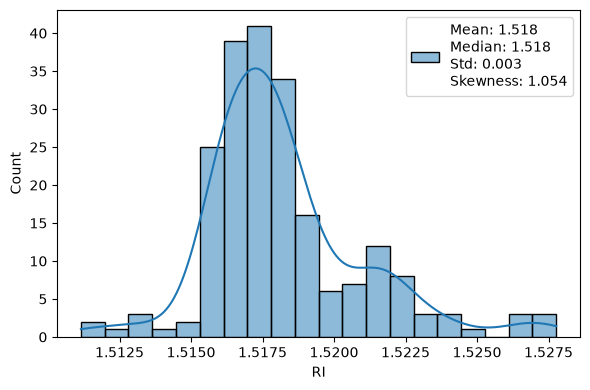

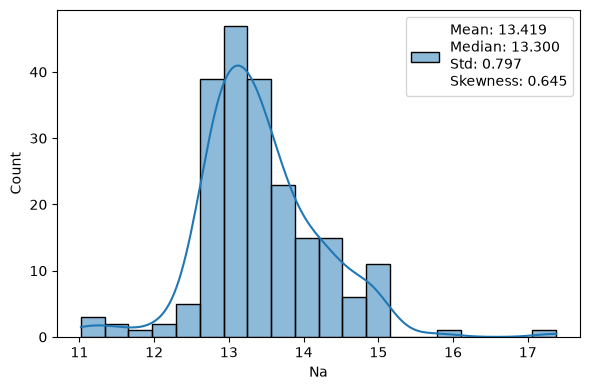

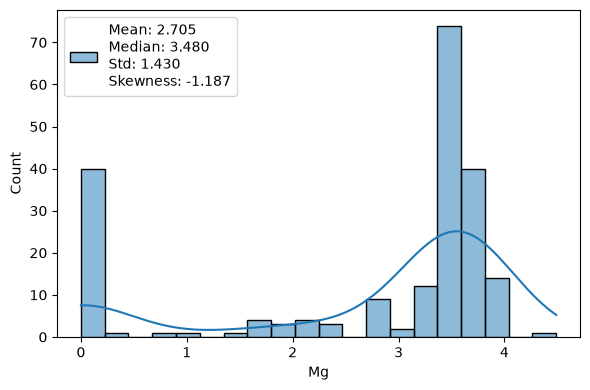

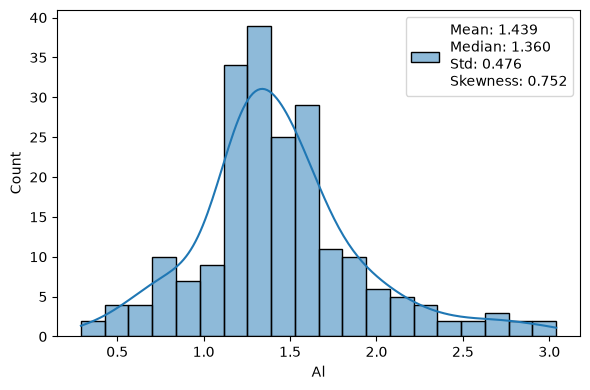

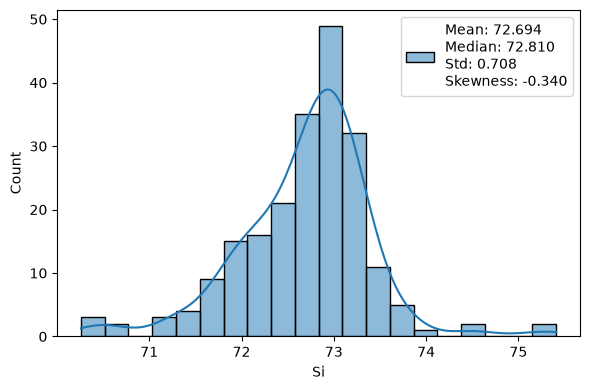

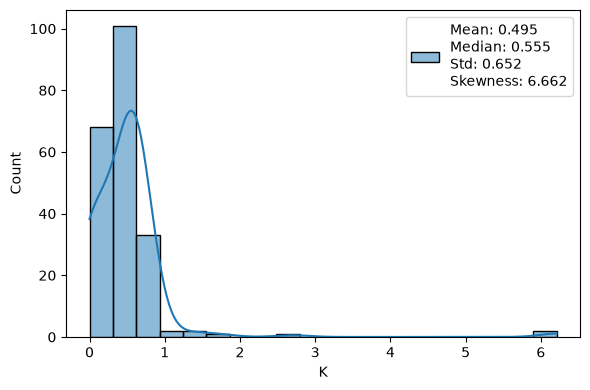

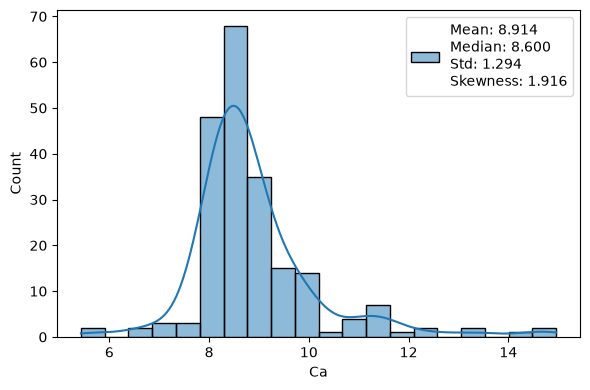

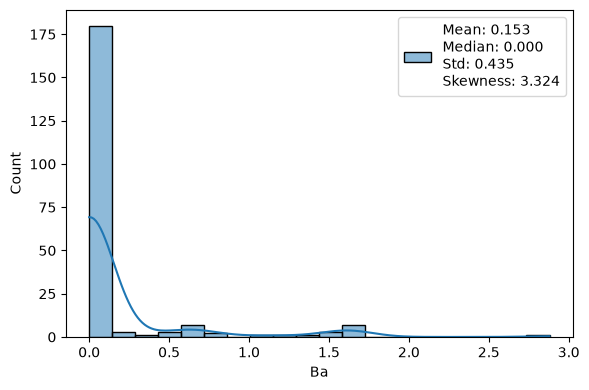

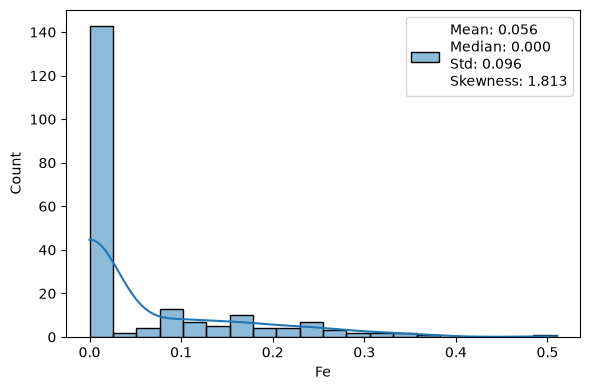

In [67]:
# visualizing features after dropping outliers
plot_feature_distribution(df)

In [70]:
# save the clean dataset
df.to_csv(path_or_buf="../data/glass_clean.csv")

In [71]:
pd.read_csv("../data/glass_clean.csv")

,Unnamed: 0,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
205,205,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
206,206,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
207,207,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
208,208,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7
